## 0. Setup and configuration

In [ ]:
import re, json, zipfile, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import (KFold, GroupKFold, LeaveOneGroupOut,
                                     GroupShuffleSplit, train_test_split)
warnings.filterwarnings("ignore", category=FutureWarning)

# ----------------------------- paths ---------------------------------------
HR_IR_ZIP_DIR = Path(r"C:\Users\user\Desktop\HRandIRzips")
GPS_DIR       = Path(r"C:\Users\user\Desktop\GPSzips")
OUT_DIR       = Path(r"C:\Users\user\Desktop\DHS_merged_output")
FEATURE_DIR   = Path(r"C:\Users\user\Downloads\DHS_FEATURES_BY_YEAR")   # dhs_features_year_*.csv
GRID_DIR      = Path(r"C:\Users\user\Downloads\GEE_25KM_RICH")          # 25 km grid CSVs
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS_CSV = OUT_DIR / "dhs_labels_v2.csv"
MATCH_CSV  = OUT_DIR / "survey_match_report.csv"

# ----------------------------- switches ------------------------------------
REBUILD_LABELS      = True    # True = rerun DHS extraction (section 1). Set False once dhs_labels_v2.csv exists.
RUN_PIXEL_BASELINE  = True    # leaky random pixel split (explains the old R2 = 0.69). Slow-ish, ~1.2M rows.
RUN_ABLATION        = True    # LOCO with feature subsets
RUN_RELATIVE_EXP    = True    # LOCO with within-survey relative features (evaluation only)

# ----------------------------- parameters ----------------------------------
SEED          = 42
N_FOLDS       = 5
BLOCK_DEG     = 2             # spatial block size for spatial CV (degrees)
MAX_KM_TO_DHS = 500           # map is masked to grid points within this distance of a DHS cluster
MIN_CLUSTERS  = 30            # surveys with fewer labelled clusters are dropped

FEATURES_RAW = [
    "red_mean","red_std","nir_mean","nir_std","blue_mean","blue_std",
    "green_mean","green_std","swir1_mean","swir1_std","swir2_mean","swir2_std",
    "ndvi_mean","ndvi_std","ndvi_min","ndvi_max",
    "evi_mean","evi_std","evi_min","evi_max",
    "lst_day_mean","lst_day_std","lst_night_mean","lst_night_std",
    "rain_mean","rain_std","elev","slope","lai_mean","lai_std",
    "nl_mean","nl_max","nl_std","lc_type1",
]
# nl_viirs: 1 if nightlights come from VIIRS (survey year >= 2012), 0 if DMSP (different scale)
FEATURES = FEATURES_RAW + ["nl_viirs"]
NL_COLS  = ["nl_mean", "nl_max", "nl_std"]
CLIMATE_PROXIES = ["rain_mean","rain_std","elev","lst_day_mean","lst_day_std",
                   "lst_night_mean","lst_night_std"]

# Same settings for every regime. subsample_freq=1 is required for subsample to take effect in LightGBM.
HIGH_PARAMS = dict(
    n_estimators=5000, learning_rate=0.02, max_depth=6, num_leaves=63,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8, min_child_samples=50,
    n_jobs=-1, random_state=SEED, importance_type="gain", verbose=-1,
)

## 1. DHS wealth labels 

In [2]:
def unzip_all(zip_dir: Path):
    for zpath in zip_dir.glob("*.zip"):
        folder = zip_dir / zpath.stem
        if folder.exists():
            continue
        try:
            with zipfile.ZipFile(zpath, "r") as zf:
                folder.mkdir(exist_ok=True)
                zf.extractall(folder)
            print("Unzipped:", zpath.name)
        except Exception as e:
            print("Failed to unzip", zpath.name, e)

unzip_all(HR_IR_ZIP_DIR)
unzip_all(GPS_DIR)

In [3]:
if LABELS_CSV.exists() and not REBUILD_LABELS:
    print("Using existing", LABELS_CSV, "(set REBUILD_LABELS=True to rebuild)")
else:
    import geopandas as gpd
    import pyreadstat

    def _read(path: Path, wanted):
        reader = pyreadstat.read_dta if path.suffix.lower() == ".dta" else pyreadstat.read_sav
        _, meta = reader(str(path), metadataonly=True)
        lower = {c.lower(): c for c in meta.column_names}
        missing = [w for w in wanted if w not in lower]
        if missing:
            raise KeyError(f"{path.name} lacks {missing}")
        df, _ = reader(str(path), usecols=[lower[w] for w in wanted])
        df.columns = [c.lower() for c in df.columns]
        return df

    def to_gregorian(y):
        y = int(y)
        if y > 2060:            return y - 57     # Nepal (Bikram Sambat)
        if 1300 <= y < 1500:    return y + 621    # Afghanistan (Solar Hijri)
        return y

    def files_of(folder: Path, kind: str):
        # DHS file names: CCKKRRxx.ext  -> characters 2:4 give the recode type (HR, IR, GE ...)
        return sorted(p for p in folder.iterdir()
                      if p.suffix.lower() in (".dta", ".sav") and p.name[2:4].upper() == kind)

    def survey_key(folder: Path):
        return folder.name[:2].upper() + folder.name[4:6].upper()

    # ---- wealth tables per survey (HR first, IR only as fallback) -----------
    surveys = {}
    folders = sorted(p for p in HR_IR_ZIP_DIR.iterdir() if p.is_dir())
    for kind in ("HR", "IR"):
        for folder in folders:
            fl = files_of(folder, kind)
            key = survey_key(folder)
            if not fl or key in surveys:
                continue
            try:
                if kind == "HR":
                    df = _read(fl[0], ["hv001", "hv007", "hv270", "hv271"])
                    tab = df.groupby("hv001", as_index=False).agg(
                        wealth_quintile=("hv270", "mean"),
                        wealth_score=("hv271", "mean"),
                        n_hh=("hv271", "size")).rename(columns={"hv001": "DHSCLUST"})
                    year = df["hv007"].mode().iat[0]
                else:
                    df = _read(fl[0], ["v001", "v007", "v190", "v191"])
                    tab = df.groupby("v001", as_index=False).agg(
                        wealth_quintile=("v190", "mean"),
                        wealth_score=("v191", "mean"),
                        n_hh=("v191", "size")).rename(columns={"v001": "DHSCLUST"})
                    year = df["v007"].mode().iat[0]
                tab["DHSCLUST"] = tab["DHSCLUST"].astype(int)
                surveys[key] = dict(key=key, country=key[:2], kind=kind,
                                    year=int(year), table=tab, folder=folder.name)
                print(f"{kind}: {folder.name:12s} -> {len(tab):5d} clusters, year {int(year)}")
            except Exception as e:
                print(f"{kind} failed for {folder.name}: {e}")

    # ---- GPS surveys ---------------------------------------------------------
    gps_list = []
    for folder in sorted(p for p in GPS_DIR.iterdir() if p.is_dir()):
        shp = sorted(folder.glob("*.shp"))
        if not shp:
            continue
        gps = gpd.read_file(shp[0])
        gps["DHSCLUST"] = gps["DHSCLUST"].astype(int)
        gps_list.append(dict(key=survey_key(folder), country=folder.name[:2].upper(),
                             year=int(gps["DHSYEAR"].mode().iat[0]), gps=gps, folder=folder.name))

    # ---- match GPS surveys to wealth tables ----------------------------------
    merged_list, report = [], []
    for cc in sorted({g["country"] for g in gps_list}):
        G = sorted([g for g in gps_list if g["country"] == cc], key=lambda g: g["year"])
        S = sorted([s for s in surveys.values() if s["country"] == cc],
                   key=lambda s: to_gregorian(s["year"]))
        pairs, how = [], ""
        if len(G) == len(S) and len(G) > 0:
            pairs, how = list(zip(G, S)), "order"
        else:
            how, used = "year", set()
            for g in G:
                cands = sorted([s for s in S if s["key"] not in used],
                               key=lambda s: abs(to_gregorian(s["year"]) - g["year"]))
                if cands and abs(to_gregorian(cands[0]["year"]) - g["year"]) <= 2:
                    pairs.append((g, cands[0])); used.add(cands[0]["key"])
                else:
                    report.append(dict(country=cc, gps=g["folder"], wealth=None, how=how,
                                       flag="NO WEALTH TABLE MATCHED"))
        for g, s in pairs:
            m = g["gps"].merge(s["table"], on="DHSCLUST", how="left")
            m["country"], m["survey"], m["wealth_source"] = cc, g["key"], s["kind"]
            share = m["wealth_score"].notna().mean()
            yr_gap = abs(to_gregorian(s["year"]) - g["year"])
            flag = []
            if share < 0.9:  flag.append("LOW MATCH SHARE")
            if yr_gap > 2:   flag.append("YEAR GAP (check)")
            report.append(dict(country=cc, gps=g["folder"], wealth=s["folder"], how=how,
                               kind=s["kind"], gps_year=g["year"], wealth_year=s["year"],
                               n_gps=len(g["gps"]), n_wealth=len(s["table"]),
                               share_labelled=round(share, 3), flag=";".join(flag)))
            merged_list.append(m)
        if not pairs and not any(r["country"] == cc for r in report):
            report.append(dict(country=cc, gps="; ".join(g["folder"] for g in G),
                               wealth=None, how=how, flag="NO WEALTH FOR COUNTRY"))

    rep = pd.DataFrame(report)
    rep.to_csv(MATCH_CSV, index=False)
    print("\nSurvey match report saved to", MATCH_CSV)
    print("Flagged rows:")
    print(rep[rep["flag"].fillna("") != ""].to_string(index=False) if (rep["flag"].fillna("") != "").any() else "  none")

    labels = pd.concat(merged_list, ignore_index=True)
    labels = pd.DataFrame(labels.drop(columns="geometry"))
    n0 = len(labels)
    ok = labels["LATNUM"].notna() & labels["LONGNUM"].notna() & ~((labels["LATNUM"] == 0) & (labels["LONGNUM"] == 0))
    labels = labels[ok].reset_index(drop=True)
    print(f"Dropped {n0 - len(labels)} clusters with missing or (0,0) coordinates")
    labels.to_csv(LABELS_CSV, index=False)
    print(f"Saved {len(labels):,} clusters, {labels['country'].nunique()} countries, "
          f"{labels['wealth_score'].notna().mean():.1%} labelled -> {LABELS_CSV}")

HR: ALHR71DT     ->   715 clusters, year 2017
HR: AMHR72DT     ->   313 clusters, year 2016
HR: AOHR81DT     ->   630 clusters, year 2023
HR: BFHR81DT     ->   514 clusters, year 2021
HR: BJHR71DT     ->   555 clusters, year 2017
HR: BUHR71DT     ->   554 clusters, year 2016
HR: CDHR81DT     ->   778 clusters, year 2023
HR failed for CFHR31DT: "CFHR31FL.DTA lacks ['hv270', 'hv271']"
HR: CIHR81DT     ->   539 clusters, year 2021
HR: CMHR71DT     ->   430 clusters, year 2018
HR: COHR72DT     ->  4878 clusters, year 2015
HR: DRHR61DT     ->   524 clusters, year 2013
HR: DRHR6ADT     ->   114 clusters, year 2013
HR: EGHR61DT     ->  1836 clusters, year 2014
HR: ETHR81DT     ->   305 clusters, year 2011
HR: GAHR71DT     ->   390 clusters, year 2021
HR: GHHR8CDT     ->   618 clusters, year 2022
HR: GMHR81DT     ->   280 clusters, year 2020
HR: GNHR71DT     ->   401 clusters, year 2018
HR: GUHR71DT     ->   858 clusters, year 2015
HR: GYHR5IDT     ->   325 clusters, year 2009
HR: HNHR62DT    

## 2. Build the cluster-level dataset

The Earth Engine exports contain about 40 rows per cluster (one per 500 m pixel in the buffer) that all carry the same wealth label. Random splits over those rows leak, so everything honest is done on **one row per cluster** (`cl`). The pixel table (`df_pix`) is only kept for the leaky baseline.

In [4]:
labels = pd.read_csv(LABELS_CSV, low_memory=False)
labels["DHSID"] = labels["DHSID"].astype(str)

files = sorted(FEATURE_DIR.glob("dhs_features_year_*.csv"))
print(f"Found {len(files)} feature files")
keep = set(["DHSID", "DHSYEAR"] + FEATURES_RAW)
df_pix = pd.concat([pd.read_csv(f, low_memory=False, usecols=lambda c: c in keep) for f in files],
                   ignore_index=True)
df_pix["DHSID"] = df_pix["DHSID"].astype(str)
df_pix[NL_COLS] = df_pix[NL_COLS].fillna(0)          # dark = no lights
df_pix["nl_viirs"] = (df_pix["DHSYEAR"] >= 2012).astype(int)
print(f"Pixel rows: {len(df_pix):,}   unique clusters: {df_pix['DHSID'].nunique():,}")

Found 18 feature files
Pixel rows: 1,229,678   unique clusters: 30,641


In [5]:
def build_cluster_table(df_pix, labels):
    g = df_pix.groupby("DHSID")
    cl = g[[c for c in FEATURES_RAW if c != "lc_type1"] + ["nl_viirs", "DHSYEAR"]].mean()
    cl["n_pix"] = g.size()
    # land cover is categorical: take the most common class, not the mean
    lc = (df_pix.groupby(["DHSID", "lc_type1"]).size().reset_index(name="n")
                .sort_values(["DHSID", "n"], ascending=[True, False])
                .drop_duplicates("DHSID").set_index("DHSID")["lc_type1"])
    cl["lc_type1"] = lc
    cl["nl_viirs"] = (cl["DHSYEAR"] >= 2012).astype(int)
    cl = cl.reset_index()

    lab_cols = ["DHSID", "country", "survey", "wealth_score", "LATNUM", "LONGNUM"]
    if "URBAN_RURA" in labels.columns:
        lab_cols.append("URBAN_RURA")
    cl = cl.merge(labels[lab_cols], on="DHSID", how="inner")
    cl = cl.dropna(subset=FEATURES + ["wealth_score"]).reset_index(drop=True)

    # drop tiny surveys (z-scores are unstable)
    sizes = cl.groupby("survey")["DHSID"].transform("size")
    dropped = cl.loc[sizes < MIN_CLUSTERS, "survey"].unique()
    if len(dropped):
        print("Dropping surveys with <", MIN_CLUSTERS, "clusters:", list(dropped))
    cl = cl[sizes >= MIN_CLUSTERS].reset_index(drop=True)

    # relative wealth: z-score within survey, at cluster level
    cl["y"] = cl.groupby("survey")["wealth_score"].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8))
    cl["cell"] = ((cl["LATNUM"] // BLOCK_DEG).astype(int).astype(str) + "_" +
                  (cl["LONGNUM"] // BLOCK_DEG).astype(int).astype(str))
    return cl

cl = build_cluster_table(df_pix, labels)
print(f"{len(cl):,} clusters | {cl['country'].nunique()} countries | {cl['survey'].nunique()} surveys")
print("pixels per cluster:", cl["n_pix"].describe()[["min", "50%", "max"]].round(0).to_dict())
print("clusters per survey year:"); print(cl["DHSYEAR"].value_counts().sort_index().to_string())

30,521 clusters | 45 countries | 46 surveys
pixels per cluster: {'min': 1.0, '50%': 46.0, 'max': 74.0}
clusters per survey year:
DHSYEAR
2003.0     419
2005.0     363
2009.0    1283
2010.0    4252
2011.0    1123
2012.0     642
2013.0    1425
2014.0    2017
2015.0    1543
2016.0    1220
2017.0    1947
2018.0     792
2019.0    1756
2020.0     663
2021.0    1664
2022.0    3519
2023.0    3220
2024.0    2673


## 3. Evaluation helpers

All early stopping uses an **inner split of the training fold**; the outer test fold is never used to choose the model, and each fold is scored once per cluster (out-of-fold predictions).

In [6]:
def run_regime(label, splitter, groups, X, y, inner_groups=None,
               inner_frac=0.15, es_rounds=150, params=None, verbose=True):
    params = params or HIGH_PARAMS
    n_splits = splitter.get_n_splits(X, y, groups)
    oof = np.full(len(X), np.nan)
    imps = np.zeros((n_splits, X.shape[1]))
    trees = []
    for i, (tr, te) in enumerate(splitter.split(X, y, groups)):
        if inner_groups is not None:
            gss = GroupShuffleSplit(n_splits=1, test_size=inner_frac, random_state=SEED)
            a, b = next(gss.split(tr, groups=np.asarray(inner_groups)[tr]))
            itr, iva = tr[a], tr[b]
        else:
            itr, iva = train_test_split(tr, test_size=inner_frac, random_state=SEED)
        m = lgb.LGBMRegressor(**params)
        m.fit(X.iloc[itr], y.iloc[itr],
              eval_set=[(X.iloc[iva], y.iloc[iva])],
              callbacks=[lgb.early_stopping(es_rounds, verbose=False)])
        imps[i] = m.feature_importances_
        oof[te] = m.predict(X.iloc[te])
        trees.append(m.best_iteration_ or params["n_estimators"])
    assert not np.isnan(oof).any(), "some rows were never in a test fold"
    r2, mae = r2_score(y, oof), mean_absolute_error(y, oof)
    if verbose:
        print(f"{label:34s} R2 = {r2:6.3f}  MAE = {mae:5.3f}  mean trees = {np.mean(trees):6.0f} "
              f"(min {min(trees)}, max {max(trees)})")
    return dict(label=label, oof=oof, r2=r2, mae=mae, trees=trees,
                imp=pd.Series(imps.mean(axis=0), index=X.columns))


def quintile_report(cl, pred, label):
    # how well do predicted quintiles (within survey) match true quintiles?
    d = cl[["survey", "y"]].copy()
    d["pred"] = pred
    qt = d.groupby("survey")["y"].transform(lambda s: pd.qcut(s, 5, labels=False, duplicates="drop"))
    qp = d.groupby("survey")["pred"].transform(lambda s: pd.qcut(s, 5, labels=False, duplicates="drop"))
    bottom = qp == 0
    return {
        "regime": label,
        "pred poorest 20% -> truly bottom 20%": round(float((qt[bottom] == 0).mean()), 3),
        "pred poorest 20% -> truly bottom 40%": round(float((qt[bottom] <= 1).mean()), 3),
        "exact quintile": round(float((qt == qp).mean()), 3),
        "within one quintile": round(float(((qt - qp).abs() <= 1).mean()), 3),
    }
CHANCE = {"pred poorest 20% -> truly bottom 20%": 0.20, "pred poorest 20% -> truly bottom 40%": 0.40,
          "exact quintile": 0.20, "within one quintile": 0.52}


def per_group_table(cl, pred, by="country"):
    rows = []
    for k, d in cl.assign(pred=pred).groupby(by):
        if len(d) < 10:
            continue
        rows.append(dict(**{by: k}, n=len(d),
                         r2=r2_score(d["y"], d["pred"]),
                         spearman=spearmanr(d["y"], d["pred"])[0],
                         bias=d["pred"].mean()))
    return pd.DataFrame(rows).sort_values("spearman")

## 4. Validation regimes

| Regime | What it tests |
|---|---|
| Random **pixel** split | memorising clusters already seen (leaky baseline, the old R² of 0.69) |
| Random **cluster** split | unseen clusters, but their neighbours are in training |
| Spatial blocks | unseen nearby regions |
| Leave-one-country-out | a completely new country |

In [7]:
X, y = cl[FEATURES], cl["y"]
REG = {}

REG["random cluster split"] = run_regime(
    "random cluster split", KFold(N_FOLDS, shuffle=True, random_state=SEED), None, X, y)

REG["spatial blocks"] = run_regime(
    f"spatial blocks ({BLOCK_DEG} deg)", GroupKFold(N_FOLDS), cl["cell"], X, y,
    inner_groups=cl["cell"].values)

REG["leave-one-country-out"] = run_regime(
    "leave-one-country-out", LeaveOneGroupOut(), cl["country"], X, y,
    inner_groups=cl["country"].values)

random cluster split               R2 =  0.594  MAE = 0.470  mean trees =   3296 (min 2477, max 4274)
spatial blocks (2 deg)             R2 =  0.438  MAE = 0.554  mean trees =   1055 (min 501, max 1457)
leave-one-country-out              R2 =  0.247  MAE = 0.645  mean trees =    164 (min 53, max 382)


In [8]:
# Leaky baseline on the PIXEL table: same cluster appears on both sides of the split.
pixel_result = None
if RUN_PIXEL_BASELINE:
    dp = df_pix.merge(cl[["DHSID", "y"]], on="DHSID", how="inner").dropna(subset=FEATURES_RAW + ["y"])
    Xp, yp = dp[FEATURES], dp["y"]
    tr, te = train_test_split(np.arange(len(dp)), test_size=0.2, random_state=SEED)
    itr, iva = train_test_split(tr, test_size=0.15, random_state=SEED)
    m = lgb.LGBMRegressor(**HIGH_PARAMS)
    m.fit(Xp.iloc[itr], yp.iloc[itr], eval_set=[(Xp.iloc[iva], yp.iloc[iva])],
          callbacks=[lgb.early_stopping(150, verbose=False)])
    p = m.predict(Xp.iloc[te])
    pixel_result = dict(r2=r2_score(yp.iloc[te], p), trees=m.best_iteration_,
                        imp=pd.Series(m.feature_importances_, index=FEATURES))
    print(f"random PIXEL split (leaky)         R2 = {pixel_result['r2']:6.3f}  trees = {pixel_result['trees']}")
    del dp, Xp, yp

random PIXEL split (leaky)         R2 =  0.685  trees = 5000


## 5. Results summary: regimes, ranking metrics, per-country performance

In [9]:
rows = []
if pixel_result is not None:
    rows.append(dict(regime="random pixel split (leaky)", R2=pixel_result["r2"], MAE=np.nan,
                     mean_trees=pixel_result["trees"]))
for k, v in REG.items():
    rows.append(dict(regime=v["label"], R2=v["r2"], MAE=v["mae"], mean_trees=np.mean(v["trees"])))
summary = pd.DataFrame(rows).round(3)
print(summary.to_string(index=False))
summary.to_csv(OUT_DIR / "results_regimes.csv", index=False)

# --- ranking quality (quintiles) for the two realistic regimes -----------------
qrows = [quintile_report(cl, REG["spatial blocks"]["oof"], "spatial blocks"),
         quintile_report(cl, REG["leave-one-country-out"]["oof"], "leave-one-country-out")]
qtab = pd.DataFrame(qrows).set_index("regime")
qtab.loc["chance"] = pd.Series(CHANCE)
print("\nQuintile hit-rates (chance in last row):")
print(qtab.to_string())
qtab.to_csv(OUT_DIR / "results_quintiles.csv")

# --- per-country performance under LOCO -----------------------------------------
cl["oof_loco"] = REG["leave-one-country-out"]["oof"]
cl["oof_spatial"] = REG["spatial blocks"]["oof"]
ctab = per_group_table(cl, cl["oof_loco"], "country")
print("\nLOCO per country (sorted by Spearman; R2 also penalises country-level offset = 'bias'):")
print(ctab.round(3).to_string(index=False))
ctab.to_csv(OUT_DIR / "results_loco_by_country.csv", index=False)
print("\nmedian Spearman across countries (LOCO):", round(ctab["spearman"].median(), 3))
print("countries with Spearman < 0.2:", ctab.loc[ctab["spearman"] < 0.2, "country"].tolist())

                    regime    R2   MAE  mean_trees
random pixel split (leaky) 0.685   NaN    5000.000
      random cluster split 0.594 0.470    3295.600
    spatial blocks (2 deg) 0.438 0.554    1054.800
     leave-one-country-out 0.247 0.645     163.667

Quintile hit-rates (chance in last row):
                       pred poorest 20% -> truly bottom 20%  pred poorest 20% -> truly bottom 40%  exact quintile  within one quintile
regime                                                                                                                                
spatial blocks                                        0.445                                 0.717           0.393                0.781
leave-one-country-out                                 0.387                                 0.640           0.355                0.724
chance                                                0.200                                 0.400           0.200                0.520

LOCO per country (sorted by

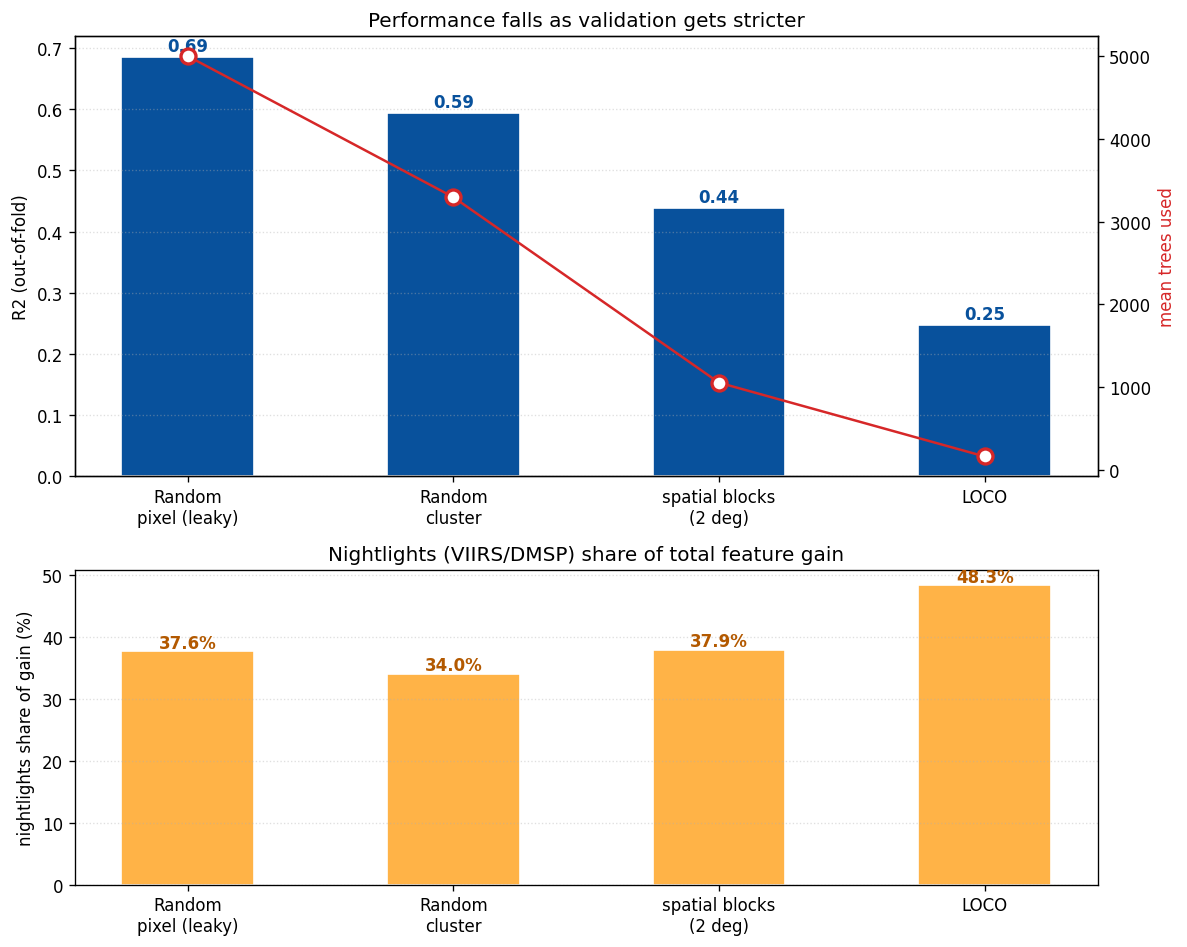

In [10]:
# Figure: R2 per regime, trees used, and nightlights' share of gain
labels_fig, r2s, trees_mean, nl_share = [], [], [], []
if pixel_result is not None:
    labels_fig.append("Random\npixel (leaky)"); r2s.append(pixel_result["r2"])
    trees_mean.append(pixel_result["trees"])
    imp = pixel_result["imp"]; nl_share.append(100 * imp[NL_COLS].sum() / imp.sum())
for k, v in REG.items():
    labels_fig.append(v["label"].replace(" (", "\n(").replace("random cluster split", "Random\ncluster")
                      .replace("leave-one-country-out", "LOCO"))
    r2s.append(v["r2"]); trees_mean.append(np.mean(v["trees"]))
    nl_share.append(100 * v["imp"][NL_COLS].sum() / v["imp"].sum())

fig, (a1, a3) = plt.subplots(2, 1, figsize=(10, 8), dpi=120, gridspec_kw={"height_ratios": [1.4, 1]})
x = np.arange(len(labels_fig)); a2 = a1.twinx()
bars = a1.bar(x, r2s, 0.5, color="#08519c", edgecolor="white")
for r, v in zip(bars, r2s):
    a1.text(r.get_x() + r.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold", color="#08519c")
a2.plot(x, trees_mean, "o-", color="#d62728", mfc="white", mew=2, ms=9)
a1.set_xticks(x); a1.set_xticklabels(labels_fig); a1.set_ylabel("R2 (out-of-fold)")
a2.set_ylabel("mean trees used", color="#d62728"); a1.grid(axis="y", ls=":", alpha=.4)
a1.set_title("Performance falls as validation gets stricter")
a3.bar(x, nl_share, 0.5, color="#ffb347", edgecolor="white")
for xi, v in zip(x, nl_share):
    a3.text(xi, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", color="#b35900")
a3.set_xticks(x); a3.set_xticklabels(labels_fig); a3.set_ylabel("nightlights share of gain (%)")
a3.set_title("Nightlights (VIIRS/DMSP) share of total feature gain"); a3.grid(axis="y", ls=":", alpha=.4)
plt.tight_layout(); plt.savefig(OUT_DIR / "validation_regimes.png", dpi=200, bbox_inches="tight"); plt.show()

## 6. Optional experiments (leave-one-country-out)

* **Ablation**: does removing the climate variables (rainfall, elevation, LST) help or hurt transfer to new countries? Gain share is relative, so this checks the claim directly.
* **Relative features**: the target is relative within a survey, so the features can be made relative too (percentile rank within the survey). This is **evaluation only** — using it on the grid would require assigning every grid point to a country.

In [11]:
abl = {}
if RUN_ABLATION:
    subsets = {
        "all features": FEATURES,
        "no climate proxies": [f for f in FEATURES if f not in CLIMATE_PROXIES],
        "nightlights only (+sensor flag)": NL_COLS + ["nl_viirs"],
        "no nightlights": [f for f in FEATURES if f not in NL_COLS],
    }
    for name, fs in subsets.items():
        if name == "all features":
            abl[name] = REG["leave-one-country-out"]["r2"]; continue
        r = run_regime(f"LOCO | {name}", LeaveOneGroupOut(), cl["country"], cl[fs], y,
                       inner_groups=cl["country"].values)
        abl[name] = r["r2"]
    print("\nAblation (LOCO R2):", {k: round(v, 3) for k, v in abl.items()})
    pd.Series(abl, name="LOCO_R2").to_csv(OUT_DIR / "results_ablation.csv")

LOCO | no climate proxies          R2 =  0.218  MAE = 0.656  mean trees =    115 (min 52, max 209)
LOCO | nightlights only (+sensor flag) R2 =  0.190  MAE = 0.677  mean trees =    215 (min 68, max 355)
LOCO | no nightlights              R2 =  0.185  MAE = 0.711  mean trees =    206 (min 96, max 516)

Ablation (LOCO R2): {'all features': 0.247, 'no climate proxies': 0.218, 'nightlights only (+sensor flag)': 0.19, 'no nightlights': 0.185}


In [12]:
if RUN_RELATIVE_EXP:
    rel_cols = [f for f in FEATURES_RAW if f != "lc_type1"]
    rel = cl.groupby("survey")[rel_cols].rank(pct=True)
    rel.columns = [c + "_rel" for c in rel.columns]
    Xrel = pd.concat([rel, cl[["lc_type1"]]], axis=1)
    r_rel = run_regime("LOCO | relative features", LeaveOneGroupOut(), cl["country"], Xrel, y,
                       inner_groups=cl["country"].values)
    print("vs absolute features:", round(REG["leave-one-country-out"]["r2"], 3),
          "-> relative:", round(r_rel["r2"], 3))

LOCO | relative features           R2 =  0.385  MAE = 0.591  mean trees =    284 (min 90, max 1152)
vs absolute features: 0.247 -> relative: 0.385


## 7. Final model

Trained on **all clusters** (one row each). The number of trees is the mean chosen by the leave-one-country-out folds, because the map is applied to places the model has not seen and a smaller model is the safer choice (more trees mostly sharpen memorisation of known locations).

trees for final model: 163
nl_mean           41.7
lst_night_std      6.6
nl_viirs           5.0
rain_mean          4.7
evi_mean           4.1
nl_std             3.8
nl_max             3.7
rain_std           3.7
elev               3.0
lc_type1           2.4
lst_night_mean     2.2
lst_day_std        2.2


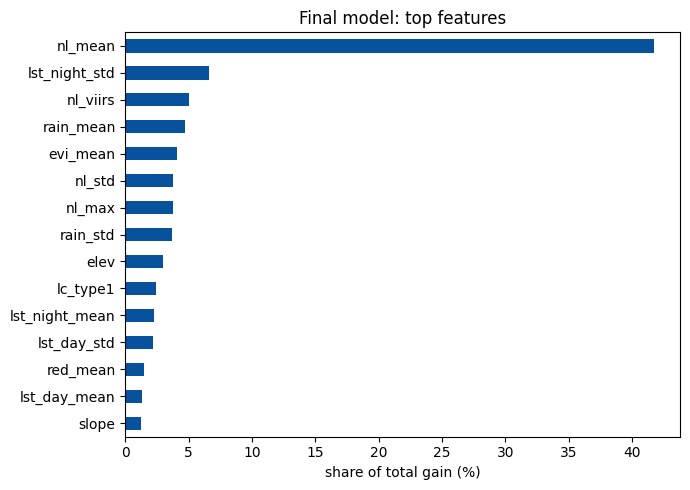

In [13]:
n_trees = int(np.mean(REG["leave-one-country-out"]["trees"]))
print("trees for final model:", n_trees)
final = lgb.LGBMRegressor(**{**HIGH_PARAMS, "n_estimators": n_trees})
final.fit(cl[FEATURES], cl["y"])
final.booster_.save_model(str(OUT_DIR / "final_model.txt"))

imp = pd.Series(final.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp_pct = 100 * imp / imp.sum()
print(imp_pct.head(12).round(1).to_string())
imp_pct.head(15)[::-1].plot(kind="barh", figsize=(7, 5), color="#08519c")
plt.xlabel("share of total gain (%)"); plt.title("Final model: top features"); plt.tight_layout(); plt.show()

## 8. Global prediction on the 25 km grid (full-world map + training-domain map)

* Duplicate grid points (overlapping region rectangles) are removed.
* Missing values are imputed in a way that mirrors training: nightlights and LAI -> 0 (dark / no vegetation), everything else -> the **training** median (not the grid median). The number of imputed values per column is printed.
* The grid is always treated as VIIRS-era (`nl_viirs = 1`).
* Every grid point is predicted and drawn on the **full-world map**. Points are also flagged `in_domain` if they lie **within `MAX_KM_TO_DHS` km of a DHS cluster**; a second map shows only those. Outside that zone (e.g. USA, Europe, Australia, China) the model is extrapolating, so read the full map there with caution.

> **Known limitation:** training features are buffer means (about 40 pixels per cluster), while grid features are single-point samples. Re-exporting the grid with the same buffer and reducer would remove this mismatch.

In [14]:
grid_files = sorted(GRID_DIR.glob("*.csv"))
print(f"{len(grid_files)} grid files")
parts = []
for f in grid_files:
    g = pd.read_csv(f, low_memory=False)
    g["region"] = re.sub(r"^global_25km_(rich_|v2_)?", "", f.stem)
    parts.append(g)
df_global = pd.concat(parts, ignore_index=True)

xy = df_global[".geo"].str.extract(r"\[\s*(-?[\d.eE+-]+)\s*,\s*(-?[\d.eE+-]+)\s*\]").astype(float)
df_global["lon"], df_global["lat"] = xy[0], xy[1]
n0 = len(df_global)
df_global = (df_global.dropna(subset=["lon", "lat"])
             .assign(_k=lambda d: d["lon"].round(4).astype(str) + "_" + d["lat"].round(4).astype(str))
             .drop_duplicates("_k").drop(columns="_k").reset_index(drop=True))
print(f"{n0:,} rows -> {len(df_global):,} after removing duplicate grid points")

missing_cols = [c for c in FEATURES_RAW if c not in df_global.columns]
assert not missing_cols, f"grid is missing columns: {missing_cols}"

train_median = cl[FEATURES_RAW].median()
imputed = {}
for c in FEATURES_RAW:
    n = int(df_global[c].isna().sum())
    if n:
        imputed[c] = n
        fill = 0 if (c in NL_COLS or c in ("lai_mean", "lai_std")) else train_median[c]
        df_global[c] = df_global[c].fillna(fill)
print("imputed values per column:", imputed if imputed else "none")
df_global["nl_viirs"] = 1

df_global["predicted_wealth"] = final.predict(df_global[FEATURES])

# ---- training-domain mask ---------------------------------------------------------
from sklearn.neighbors import BallTree
tree = BallTree(np.radians(cl[["LATNUM", "LONGNUM"]].values), metric="haversine")
d, _ = tree.query(np.radians(df_global[["lat", "lon"]].values), k=1)
df_global["km_to_dhs"] = d[:, 0] * 6371.0
df_global["in_domain"] = df_global["km_to_dhs"] <= MAX_KM_TO_DHS
print(f"mapped points: {df_global['in_domain'].sum():,} of {len(df_global):,} "
      f"({df_global['in_domain'].mean():.1%}) within {MAX_KM_TO_DHS} km of a DHS cluster")
print(df_global.loc[df_global["in_domain"], "predicted_wealth"].describe().round(3).to_string())
df_global[["lon", "lat", "region", "predicted_wealth", "km_to_dhs", "in_domain"]].to_csv(
    OUT_DIR / "global_predictions_25km.csv", index=False)

8 grid files
192,948 rows -> 161,101 after removing duplicate grid points
imputed values per column: none
mapped points: 50,992 of 161,101 (31.7%) within 500 km of a DHS cluster
count    50992.000
mean        -0.455
std          0.337
min         -2.366
25%         -0.653
50%         -0.547
75%         -0.331
max          1.800


c:\Users\makis\povertysetvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


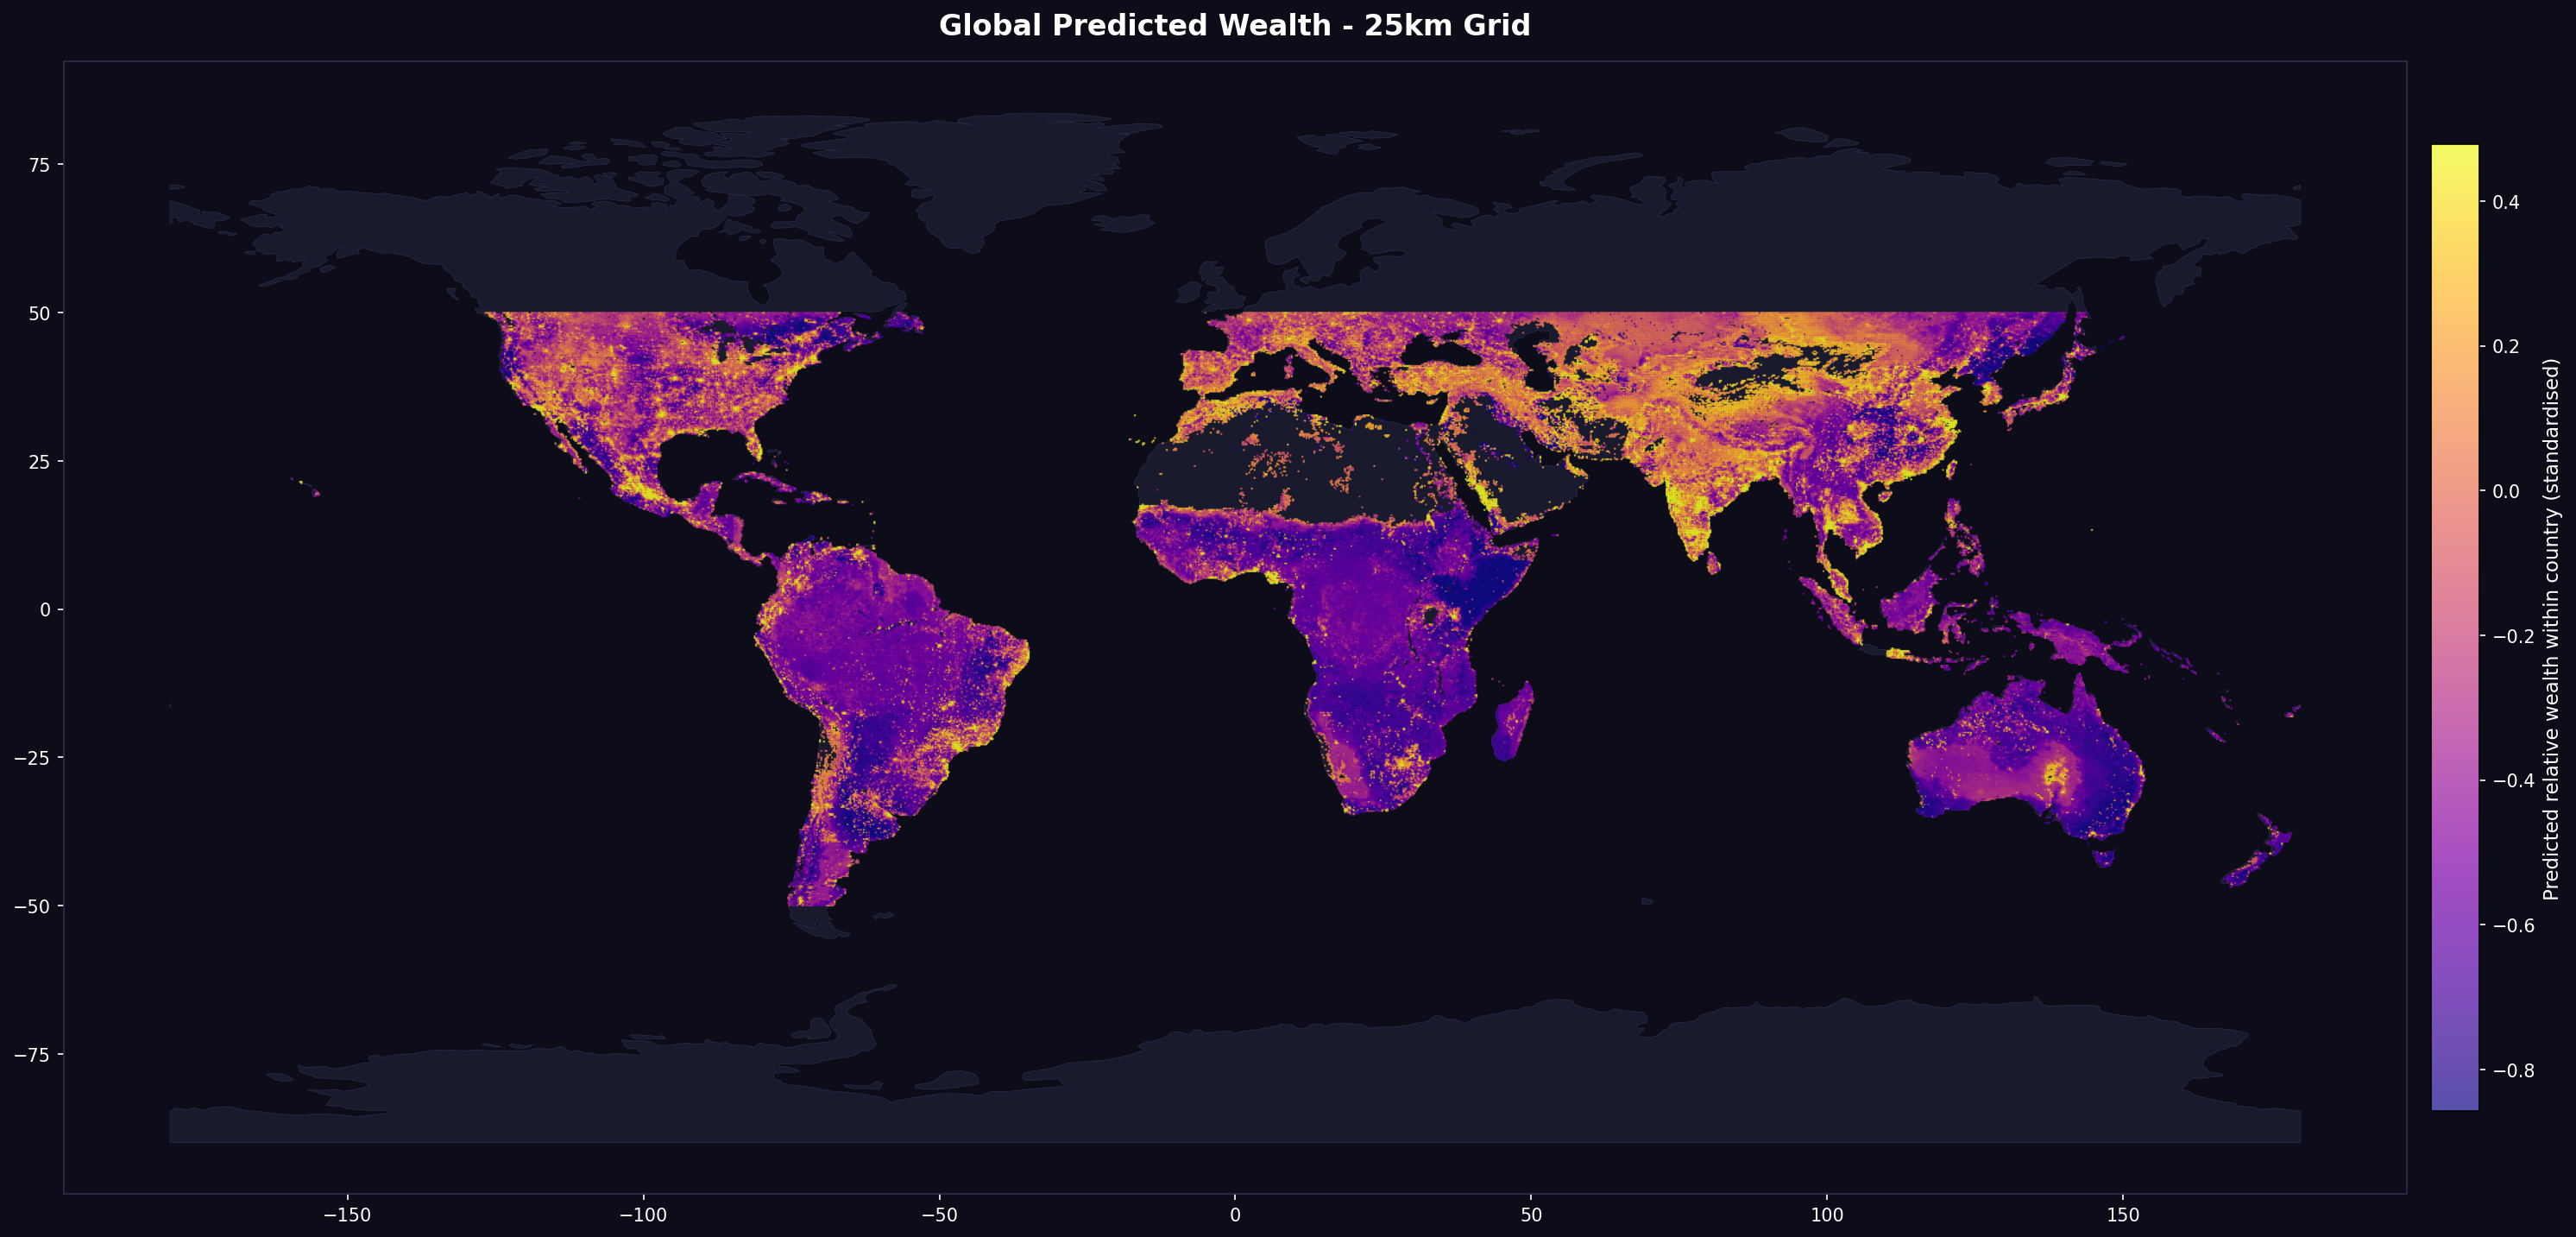

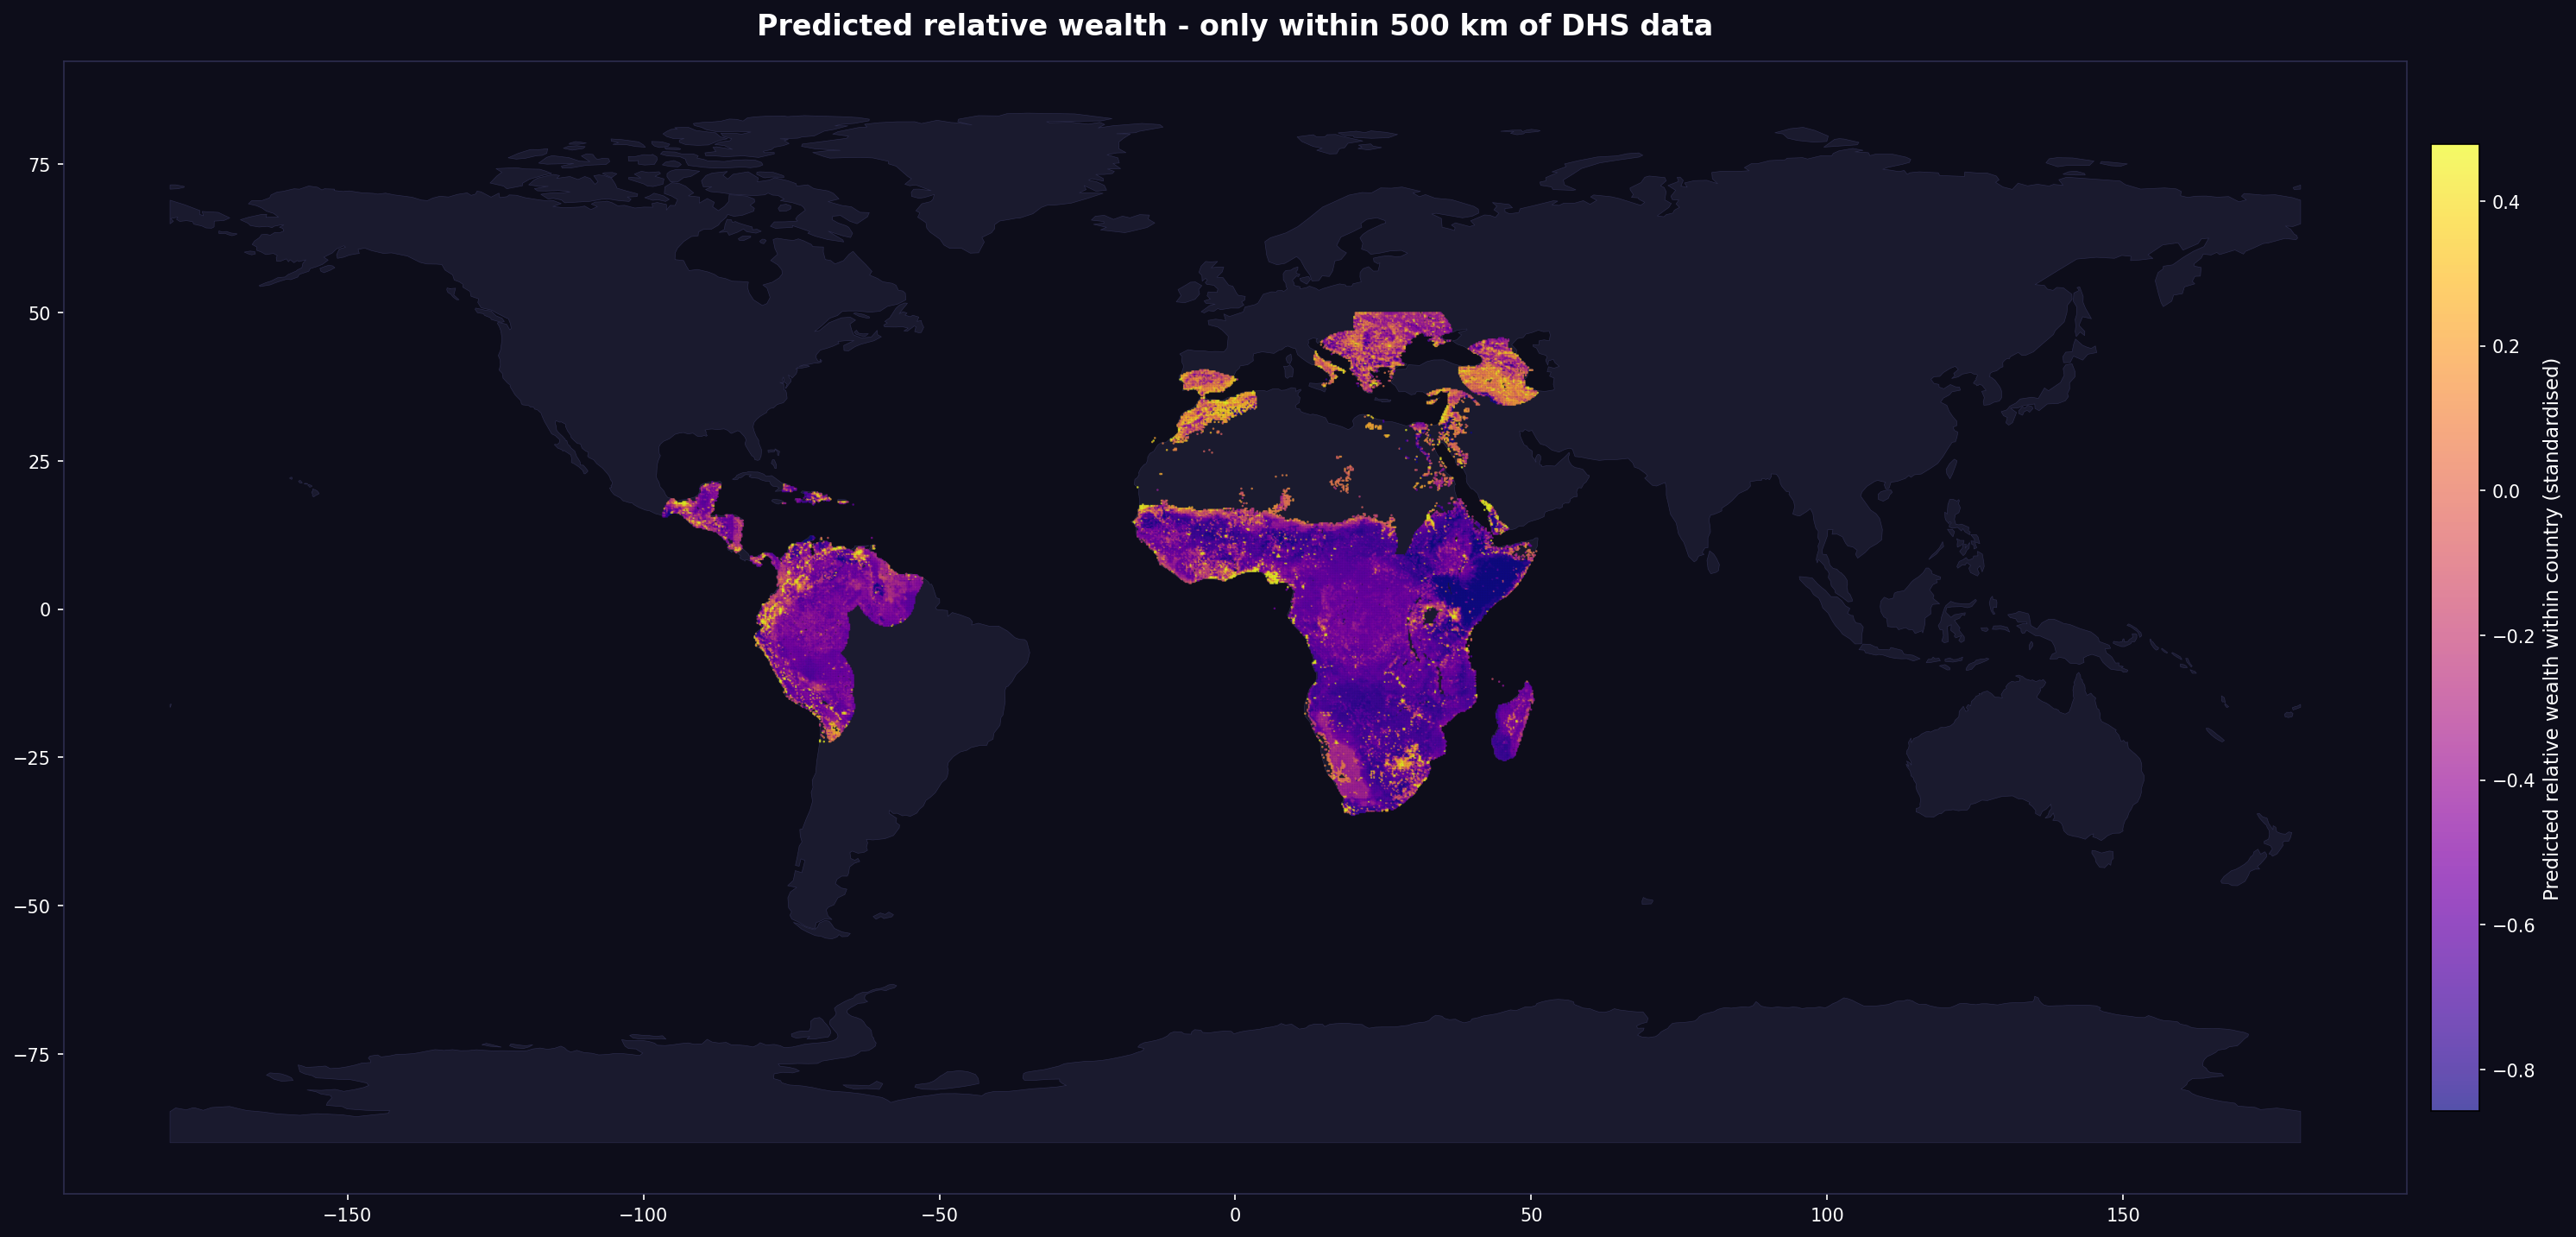

In [15]:
# Colour scale is shared by both maps (clipped at the 2nd/98th percentile of ALL grid points)
lo, hi = df_global["predicted_wealth"].quantile([0.02, 0.98])
df_global["wealth_clipped"] = df_global["predicted_wealth"].clip(lo, hi)

try:
    import geopandas as gpd, geodatasets
    world = gpd.read_file(geodatasets.get_path("naturalearth.land"))
except Exception as e:
    world = None
    print("basemap unavailable:", e)

def draw_map(points, title, path):
    fig, ax = plt.subplots(figsize=(20, 10), dpi=150)
    fig.patch.set_facecolor("#0d0d1a"); ax.set_facecolor("#0d0d1a")
    if world is not None:
        world.plot(ax=ax, color="#1a1a2e", edgecolor="#2d2d4e", linewidth=0.3)
    sc = ax.scatter(points["lon"], points["lat"], c=points["wealth_clipped"], cmap="plasma",
                    s=1.5, alpha=0.7, linewidths=0, vmin=df_global["wealth_clipped"].min(),
                    vmax=df_global["wealth_clipped"].max())
    cb = plt.colorbar(sc, ax=ax, fraction=0.02, pad=0.01)
    cb.set_label("Predicted relative wealth within country (standardised)", color="white", fontsize=11)
    cb.ax.yaxis.set_tick_params(color="white"); plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")
    ax.set_title(title, color="white", fontsize=16, fontweight="bold", pad=15)
    ax.tick_params(colors="white")
    for sp in ax.spines.values(): sp.set_edgecolor("#2d2d4e")
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

# 1) Full-world map (all grid points, as in the earlier notebook)
draw_map(df_global, "Global Predicted Wealth - 25km Grid", OUT_DIR / "global_predicted_wealth_25km.png")

# 2) Same map restricted to the training domain (within MAX_KM_TO_DHS km of a DHS cluster)
draw_map(df_global[df_global["in_domain"]],
         f"Predicted relative wealth - only within {MAX_KM_TO_DHS} km of DHS data",
         OUT_DIR / "global_predicted_wealth_25km_domain_only.png")

## 9. Final numbers 

In [16]:
print("=== HEADLINE NUMBERS (copy into the README) ===")
print(summary.to_string(index=False))
print("\nQuintile hit-rates:"); print(qtab.to_string())
print(f"\nclusters: {len(cl):,} | countries: {cl['country'].nunique()} | surveys: {cl['survey'].nunique()}")
print(f"LOCO median Spearman across countries: {ctab['spearman'].median():.2f}")

=== HEADLINE NUMBERS (copy into the README) ===
                    regime    R2   MAE  mean_trees
random pixel split (leaky) 0.685   NaN    5000.000
      random cluster split 0.594 0.470    3295.600
    spatial blocks (2 deg) 0.438 0.554    1054.800
     leave-one-country-out 0.247 0.645     163.667

Quintile hit-rates:
                       pred poorest 20% -> truly bottom 20%  pred poorest 20% -> truly bottom 40%  exact quintile  within one quintile
regime                                                                                                                                
spatial blocks                                        0.445                                 0.717           0.393                0.781
leave-one-country-out                                 0.387                                 0.640           0.355                0.724
chance                                                0.200                                 0.400           0.200                0.520



**Interpretation guide**

* Use the **spatial-block** numbers for "filling gaps between surveyed places in covered regions" and the **LOCO** numbers for "applying the model in a new country".
* The maps show **relative wealth inside each country**; the full-world map includes regions far from the training data (see `in_domain` in the predictions CSV). A value of +1 in one country is not comparable to +1 in another.
* Check `results_loco_by_country.csv`: countries with a low Spearman (typically outside the training distribution, e.g. parts of Latin America and the Middle East/North Africa) should not be trusted.
* A negative R² with a decent Spearman means a calibration offset, not a ranking failure.
* Not covered here: change over time (the grid is a single 2022 snapshot), poverty rates, or household-level targeting.

Monte Carlo country hold-out, 50 splits, ~9 countries held out each
R2               : 0.265  (sd 0.161; 5-95%: 0.009 to 0.487)
MAE              : 0.649  (sd 0.078; 5-95%: 0.531 to 0.774)
median Spearman  : 0.638  (sd 0.084; 5-95%: 0.518 to 0.766)
hit rate (bottom20): 0.392  (sd 0.059; 5-95%: 0.301 to 0.479)   [chance = 0.20]
trees            : median 89 range 6 - 604
times each country was held out: min 4 max 17


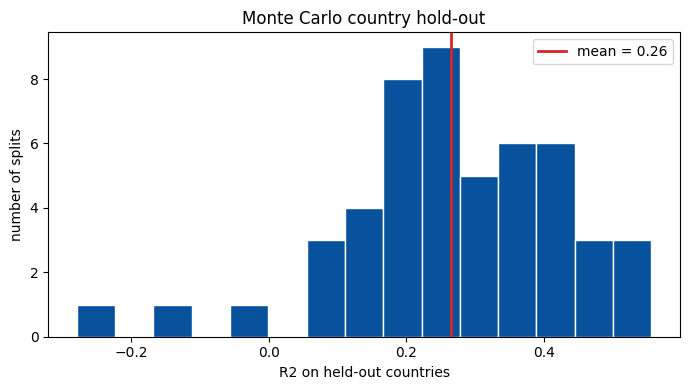

In [24]:
# ---- Monte Carlo country hold-out: repeat "train on ~80% of countries, score on the rest" ----
N_MC      = 50      # number of random splits
TEST_FRAC = 0.2     # share of countries held out in each split (~9 of 45)

mc_rows = []
splitter = GroupShuffleSplit(n_splits=N_MC, test_size=TEST_FRAC, random_state=SEED)
for i, (tr, te) in enumerate(splitter.split(cl, groups=cl["country"])):
    inner = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED + i)
    a, b = next(inner.split(tr, groups=cl["country"].values[tr]))
    itr, iva = tr[a], tr[b]                          # inner split (by country) for early stopping only

    m = lgb.LGBMRegressor(**HIGH_PARAMS)
    m.fit(cl[FEATURES].iloc[itr], cl["y"].iloc[itr],
          eval_set=[(cl[FEATURES].iloc[iva], cl["y"].iloc[iva])],
          callbacks=[lgb.early_stopping(150, verbose=False)])

    d = cl.iloc[te].copy().reset_index(drop=True)
    d["pred"] = m.predict(cl[FEATURES].iloc[te])
    sp = [spearmanr(g["y"], g["pred"])[0] for _, g in d.groupby("country") if len(g) >= 10]
    q = quintile_report(d, d["pred"].values, "mc")
    mc_rows.append(dict(split=i, n_test_countries=d["country"].nunique(), n_test=len(d),
                        r2=r2_score(d["y"], d["pred"]), mae=mean_absolute_error(d["y"], d["pred"]),
                        median_spearman=float(np.median(sp)),
                        hit_bottom20=q["pred poorest 20% -> truly bottom 20%"],
                        trees=m.best_iteration_,
                        test_countries=",".join(sorted(d["country"].unique()))))

mc = pd.DataFrame(mc_rows)
mc.to_csv(OUT_DIR / "results_montecarlo_country_holdout.csv", index=False)

def ci(s): return f"{s.mean():.3f}  (sd {s.std():.3f}; 5-95%: {s.quantile(.05):.3f} to {s.quantile(.95):.3f})"
print(f"Monte Carlo country hold-out, {N_MC} splits, ~{mc['n_test_countries'].mean():.0f} countries held out each")
print("R2               :", ci(mc["r2"]))
print("MAE              :", ci(mc["mae"]))
print("median Spearman  :", ci(mc["median_spearman"]))
print("hit rate (bottom20):", ci(mc["hit_bottom20"]), "  [chance = 0.20]")
print("trees            : median", int(mc["trees"].median()), "range", mc["trees"].min(), "-", mc["trees"].max())

from collections import Counter
cnt = Counter(c for s in mc["test_countries"] for c in s.split(","))
print("times each country was held out: min", min(cnt.values()), "max", max(cnt.values()))

plt.figure(figsize=(7, 4)); plt.hist(mc["r2"], bins=15, color="#08519c", edgecolor="white")
plt.axvline(mc["r2"].mean(), color="#d62728", lw=2, label=f"mean = {mc['r2'].mean():.2f}")
plt.xlabel("R2 on held-out countries"); plt.ylabel("number of splits")
plt.title("Monte Carlo country hold-out"); plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR / "montecarlo_r2_hist.png", dpi=200); plt.show()